In [ ]:
!pip install pandas
!pip install matplotlib
!pip install numpy


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
df=pd.read_csv("retail_sales_dataset.csv")

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 54.8+ KB


In [ ]:
df.shape

In [ ]:
df.columns

In [ ]:
print(df.isnull().sum())

In [ ]:
print(df.duplicated().sum())

In [11]:
df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
df.info()

In [ ]:
#df['Month'] = df['Date'].dt.month_name()
df.info()

In [12]:
df['Age Group'] = pd.cut(
    df['Age'],
    bins=[18,25,35,45,55,100],
    labels=['18-25','26-35','36-45','46-55','55+']
)

In [ ]:
df.info()

In [13]:
total_revenue = df['Total Amount'].sum()
total_transactions = df['Transaction ID'].nunique()
unique_customers = df['Customer ID'].nunique()
avg_order_value = df['Total Amount'].mean()
print("Total Revenue", total_revenue)
print("Unique transcations", total_transactions)
print("Unique customers", unique_customers)
print("Average order value", avg_order_value)

Total Revenue 456000
Unique transcations 1000
Unique customers 1000
Average order value 456.0


In [14]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Age Group
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,26-35
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,26-35
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,46-55
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,36-45
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,26-35


In [18]:
category_sales = (
df.groupby('Product Category')['Total Amount']
.sum()
.sort_values(ascending=False)
)

In [ ]:
category_sales

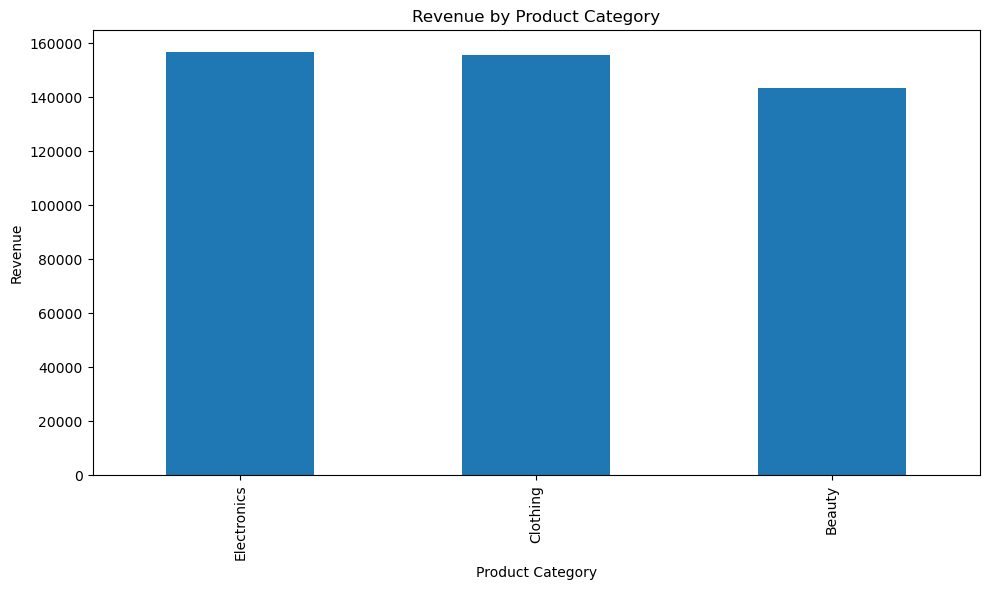

In [20]:
category_sales.plot(kind='bar', figsize=(10,6))
plt.title('Revenue by Product Category')
plt.ylabel('Revenue')
plt.tight_layout()
plt.savefig('images/category_revenue.png')
plt.show()

In [ ]:
df['Month'] = df['Date'].dt.to_period('M')
monthly_sales=df.groupby('Month')['Total Amount'].sum().sort_values(ascending=False)


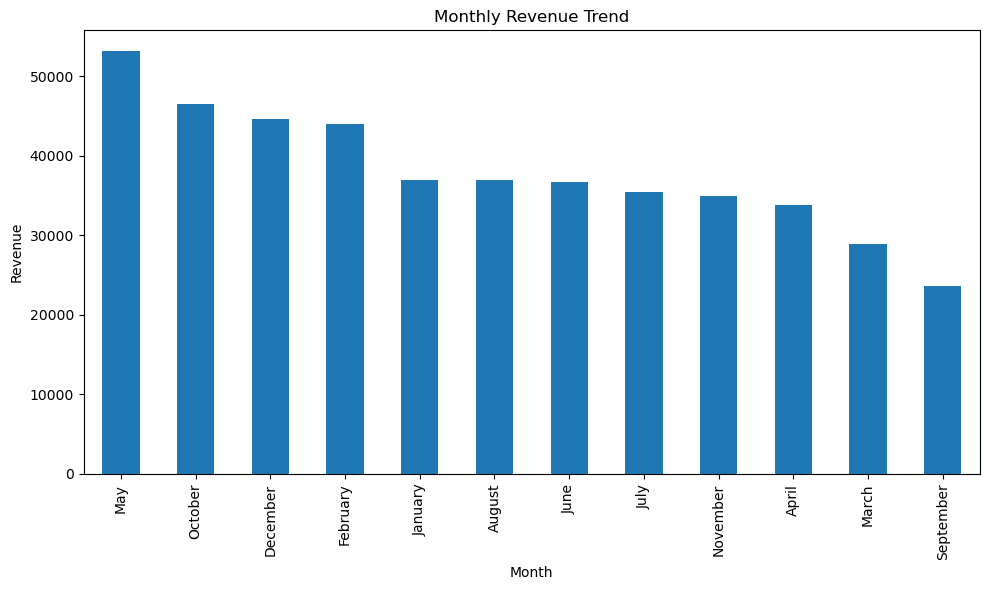

In [31]:
monthly_sales.plot(kind='bar', figsize=(10,6))
plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue')
plt.tight_layout()
plt.savefig('images/sales_trend.png')
plt.show()

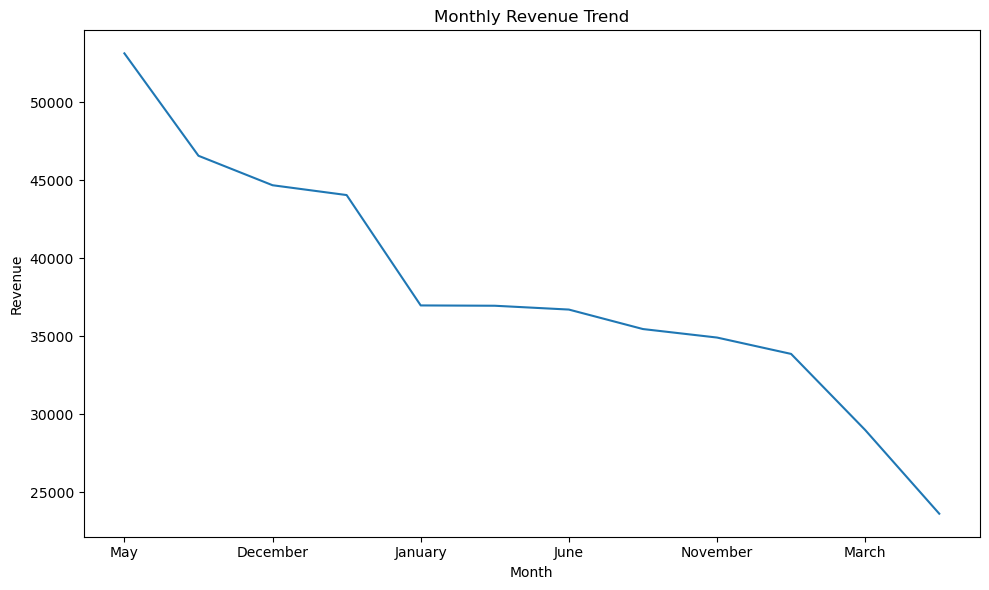

In [23]:
df['Month'] = df['Date'].dt.month_name()
monthly_sales=df.groupby('Month')['Total Amount'].sum().sort_values(ascending=False)
monthly_sales.plot(kind='line', figsize=(10,6))
plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show() 

In [24]:
age_sales = df.groupby('Age Group', observed=True)['Total Amount'].sum()

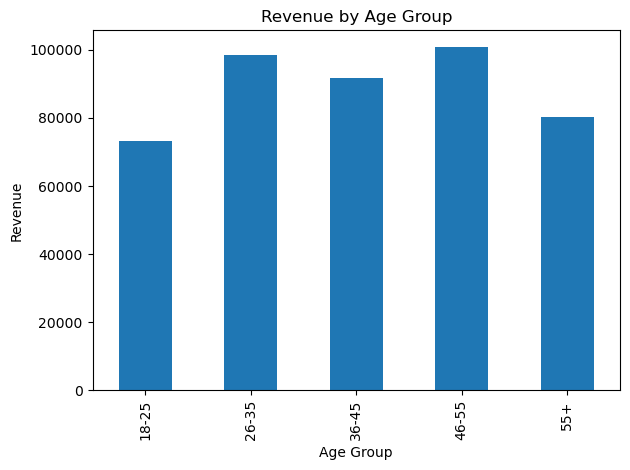

In [25]:
age_sales.plot(kind='bar')
plt.title('Revenue by Age Group')
plt.ylabel('Revenue')
plt.tight_layout()
plt.savefig('images/age_group_analysis.png')
plt.show()

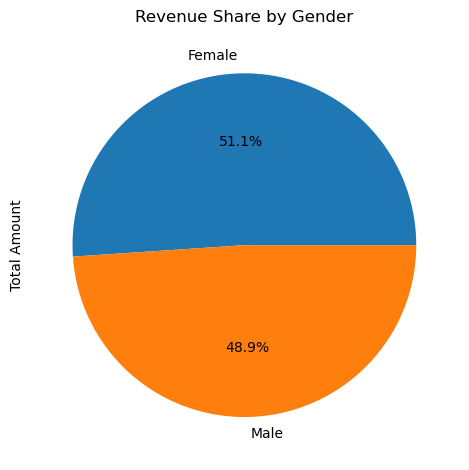

In [26]:
gender_sales = df.groupby('Gender')['Total Amount'].sum()

gender_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title('Revenue Share by Gender')
plt.tight_layout()
plt.savefig('images/gender_sale_analysis.png')
plt.show()

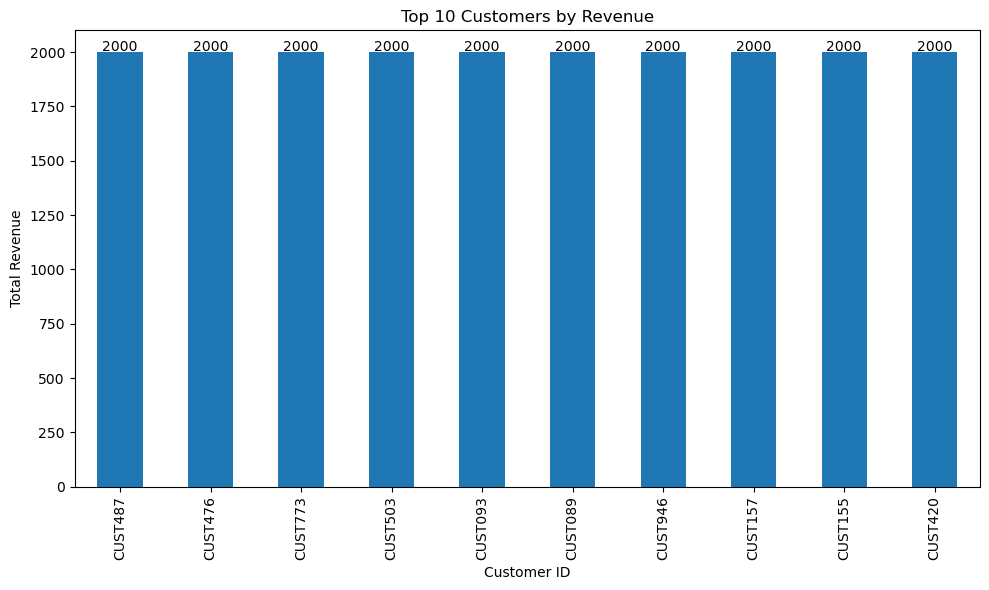

In [33]:

top_customers = df.groupby('Customer ID')['Total Amount'].sum().sort_values(ascending=False).head(10)

ax=top_customers.plot(kind='bar', figsize=(10,6))
plt.title('Top 10 Customers by Revenue')
plt.xlabel('Customer ID')
plt.ylabel('Total Revenue')

for i, v in enumerate(top_customers):
    ax.text(i, v + 5, round(v, 2), ha='center')

plt.savefig('images/Top_10_Customers.png')    
plt.tight_layout()
plt.show()


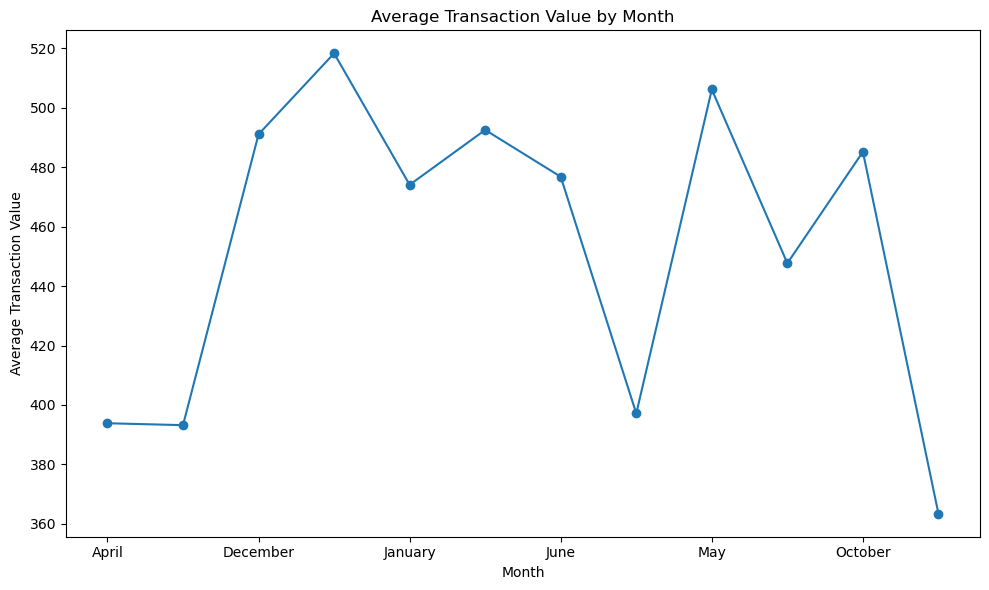

In [34]:
monthly_avg_transaction=df.groupby('Month')['Total Amount'].mean()
monthly_avg_transaction.plot(kind='line', figsize=(10,6), marker='o')
plt.title('Average Transaction Value by Month')
plt.xlabel('Month')
plt.ylabel('Average Transaction Value')
plt.savefig('images/average_transaction_month.png')
plt.tight_layout()
plt.show()

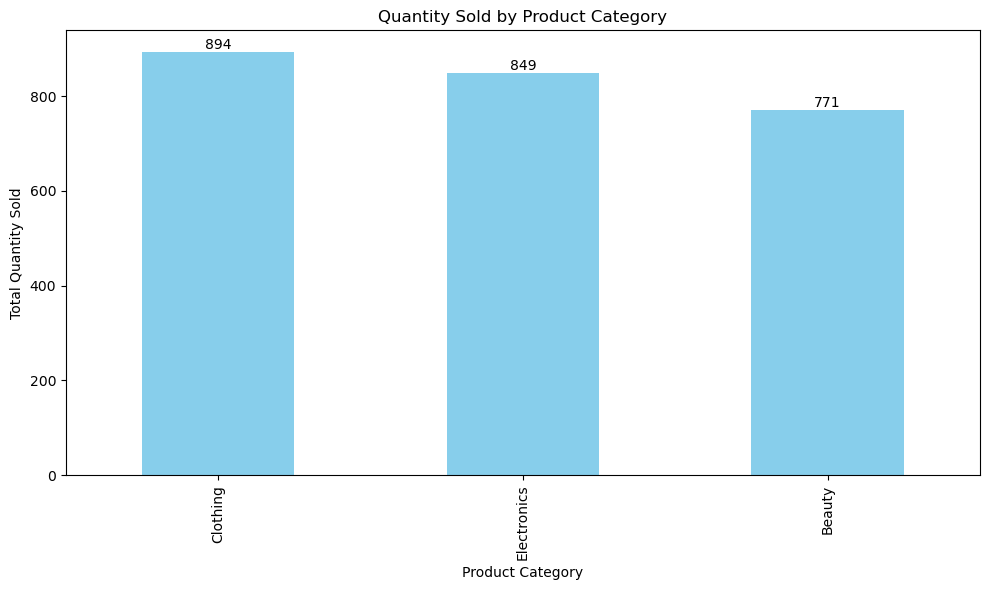

In [35]:
category_quantity = df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False)

ax = category_quantity.plot(kind='bar', figsize=(10,6), color='skyblue')
plt.title('Quantity Sold by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Quantity Sold')
plt.tight_layout()

for i, v in enumerate(category_quantity):
    ax.text(i, v + 5, str(v), ha='center')

plt.savefig('images/product_category.png')
plt.show()


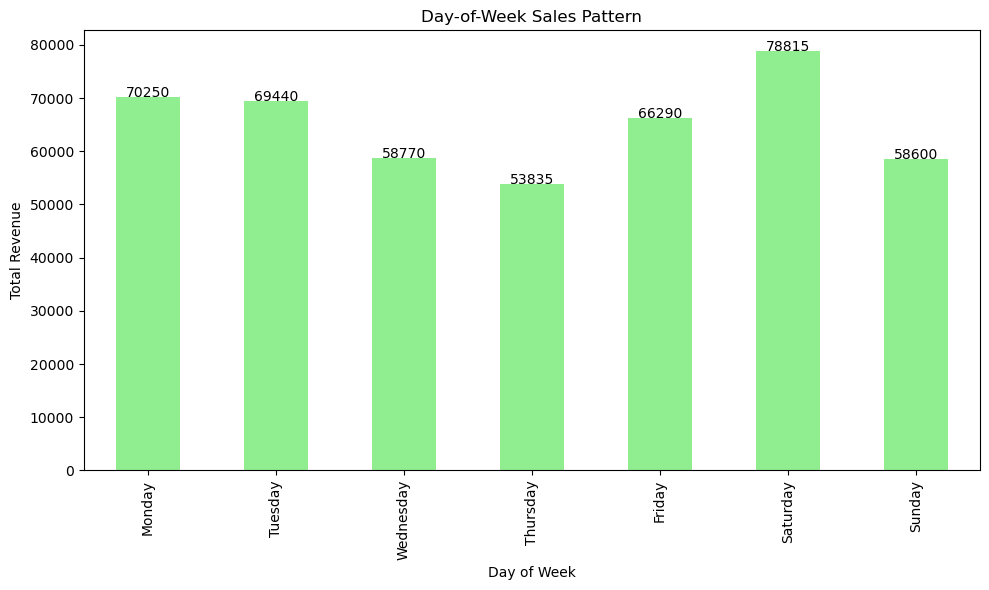

In [36]:
df['DayOfWeek'] = df['Date'].dt.day_name()

day_sales = df.groupby('DayOfWeek')['Total Amount'].sum().reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])


ax = day_sales.plot(kind='bar', figsize=(10,6), color='lightgreen')
plt.title('Day-of-Week Sales Pattern')
plt.xlabel('Day of Week')
plt.ylabel('Total Revenue')
plt.tight_layout()

for i, v in enumerate(day_sales):
    ax.text(i, v + 5, str(v), ha='center')

plt.savefig('images/day_sale.png')
plt.show()
